# VGChartz Dataset Exploration

This notebook explores the VGChartz dataset used throughout the Game Market Analysis project.

The objectives are to:

- understand the dataset structure
- assess data quality
- identify missing values and inconsistencies
- determine which fields are suitable for database integration
- identify any cleaning required before analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/raw/vgchartz-2024.csv")

In [5]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [6]:
df.sample(5)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
62398,/games/boxart/full_2777500JapanFrontccc.jpg,Nobunaga no Yabou: Bushou Fuuunsoku,GEN,Strategy,KOEI,Koei,NaN,NaN,NaN,NaN,NaN,NaN,1991-12-20,NaN
25242,/games/boxart/full_6565867AmericaFrontccc.jpg,Awakening: The Redleaf Forest,OSX,Adventure,Big Fish Games,Boomzap,NaN,NaN,NaN,NaN,NaN,NaN,2014-05-31,NaN
25882,/games/boxart/full_504630JapanFrontccc.jpg,Fushigi no Umi no Nadia: Inherit the Blue Water,PS2,Adventure,GeneX,GeneX,NaN,NaN,NaN,NaN,NaN,NaN,2005-09-22,NaN
49513,/games/boxart/full_kawaii-pet-shop-monogatari-...,Kawaii Pet Shop Monogatari 2,GB,Role-Playing,Taito,Taito Corporation,NaN,NaN,NaN,NaN,NaN,NaN,2000-12-22,NaN
27495,/games/boxart/941433ccc.jpg,The Secret of Monkey Island,PC,Adventure,LucasArts,Lucasfilm Games,NaN,NaN,NaN,NaN,NaN,NaN,1990-01-01,NaN


In [7]:
df.shape

(64016, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [9]:
df.describe(include="all")

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
count,64016,64016,64016,64016,64016,63999,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000,56965,17879
unique,56177,39798,81,20,3383,8862,NaN,NaN,NaN,NaN,NaN,NaN,7922,1545
top,/games/boxart/default.jpg,Plants vs. Zombies,PC,Misc,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,1994-01-01,2018-01-06
freq,7810,17,12617,9304,8842,4435,NaN,NaN,NaN,NaN,NaN,NaN,515,165
mean,NaN,NaN,NaN,NaN,NaN,NaN,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000,NaN,NaN


In [10]:
df.isna().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

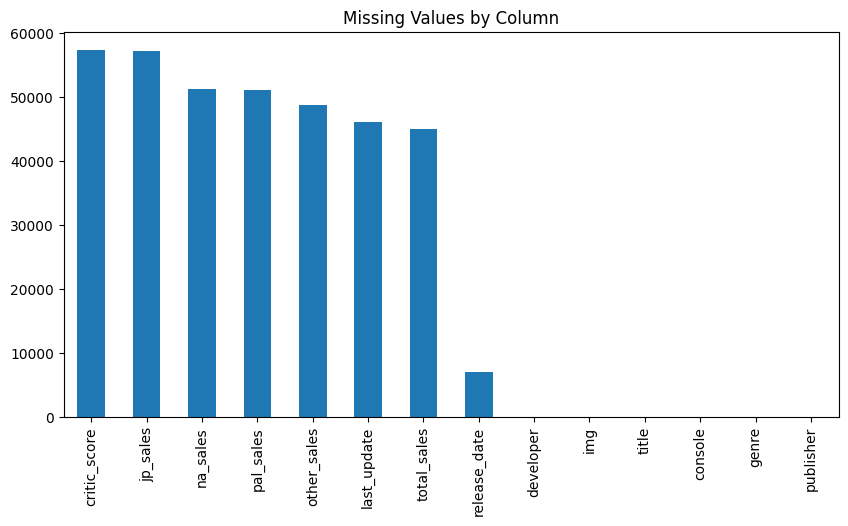

In [11]:
missing = df.isna().sum().sort_values(ascending=False)

missing.plot.bar(figsize=(10,5))
plt.title("Missing Values by Column")
plt.show()

In [12]:
df.duplicated().sum()

0

In [13]:
df["title"].duplicated().sum()

24218

In [14]:
df.duplicated(
    subset=["title","console"]
).sum()

225

In [15]:
df.dtypes

img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object

In [16]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = df["release_date"].dt.year

In [17]:
df["console"].value_counts()

console
PC      12617
PS2      3565
DS       3288
PS4      2878
PS       2707
        ...  
TG16        3
FDS         1
C128        1
Aco         1
BBCM        1
Name: count, Length: 81, dtype: int64

In [18]:
df["genre"].value_counts()

genre
Misc                9304
Action              8557
Adventure           6260
Role-Playing        5721
Sports              5586
Shooter             5410
Platform            4001
Strategy            3685
Puzzle              3521
Racing              3425
Simulation          3158
Fighting            2367
Action-Adventure    1877
Visual Novel         493
Music                297
Party                151
MMO                  115
Education             35
Board Game            33
Sandbox               20
Name: count, dtype: int64

In [19]:
df["publisher"].value_counts().head(20)

publisher
Unknown                        8842
Sega                           2207
Ubisoft                        1663
Electronic Arts                1619
Activision                     1582
Konami                         1544
Nintendo                       1476
Sony Computer Entertainment    1372
Microsoft                      1272
THQ                            1111
Capcom                         1092
Atari                           839
EA Sports                       804
Square Enix                     696
Bandai                          574
Namco Bandai                    553
Acclaim Entertainment           514
Namco Bandai Games              475
Hudson Soft                     460
Namco                           458
Name: count, dtype: int64

<Axes: >

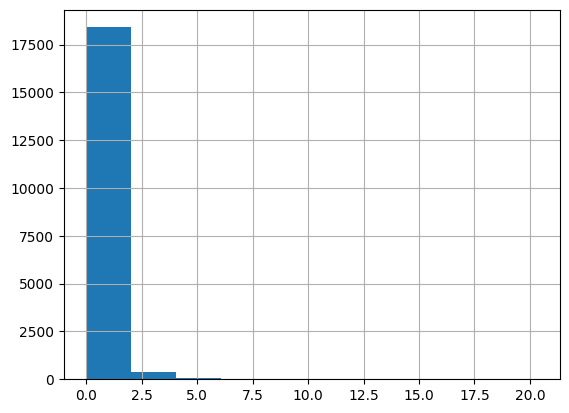

In [20]:
df["total_sales"].hist()

In [21]:
df.nlargest(
    20,
    "total_sales"
)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
5,/games/boxart/full_call-of-duty-modern-warfare...,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,0.13,4.29,1.33,2011-11-08,NaN
6,/games/boxart/full_call-of-duty-black-ops_5Ame...,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,9.76,0.11,3.73,1.14,2010-11-09,NaN
7,/games/boxart/full_4653215AmericaFrontccc.jpg,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,0.21,6.21,2.26,2018-10-26,2018-11-02
8,/games/boxart/full_1977964AmericaFrontccc.jpg,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,0.07,4.32,1.20,2012-11-13,2018-04-07
9,/games/boxart/full_4649679AmericaFrontccc.png,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,0.65,5.88,2.28,2012-11-13,2018-04-07


<Axes: >

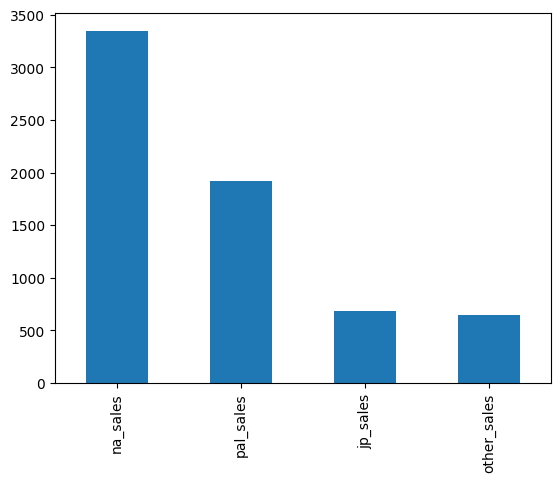

In [22]:
sales = [
    "na_sales",
    "pal_sales",
    "jp_sales",
    "other_sales"
]

df[sales].sum().plot.bar()

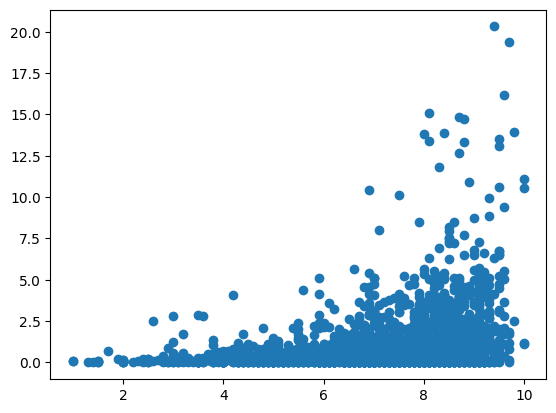

In [23]:
plt.scatter(
    df["critic_score"],
    df["total_sales"]
)